In [1]:
# Pendulum-Cart Trajectory Classification with 1D CNN
# Balanced dataset with class weights


In [2]:
# Import libraries
missing_packages = []
try:
    import numpy as np
    print(f"✓ NumPy {np.__version__}")
except ImportError:
    missing_packages.append("numpy")
    print("✗ NumPy not installed")

try:
    import torch
    print(f"✓ PyTorch {torch.__version__}")
    print(f"  CUDA available: {torch.cuda.is_available()}")
except ImportError:
    missing_packages.append("torch")
    print("✗ PyTorch not installed")

try:
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
    import sklearn
    print(f"✓ scikit-learn {sklearn.__version__}")
except ImportError:
    missing_packages.append("scikit-learn")
    print("✗ scikit-learn not installed")

try:
    import matplotlib.pyplot as plt
    print(f"✓ matplotlib")
except ImportError:
    missing_packages.append("matplotlib")
    print("✗ matplotlib not installed")

if missing_packages:
    print(f"\n⚠️  MISSING PACKAGES: {', '.join(missing_packages)}")
    print("\nTo install, run this in a terminal:")
    print(f"  pip install {' '.join(missing_packages)}")
    raise ImportError(f"Please install missing packages: {', '.join(missing_packages)}")

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

print("\n✓ All libraries imported successfully!")


✓ NumPy 2.3.3
✓ PyTorch 2.9.0+cpu
  CUDA available: False
✓ scikit-learn 1.7.2
✓ matplotlib

✓ All libraries imported successfully!


In [3]:
# Load training and validation data
train_data = np.load('trajectory_data_train.npz')
val_data = np.load('trajectory_data_val.npz')

X_train = train_data['X']
y_train = train_data['y']
ids_train = train_data['ids']

X_val = val_data['X']
y_val = val_data['y']
ids_val = val_data['ids']

print(f"Training set:")
print(f"  X shape: {X_train.shape}  (trajectories, time_steps, features)")
print(f"  y shape: {y_train.shape}  (labels)")
print(f"  Success rate: {np.mean(y_train == 1):.2%}")
print(f"  Failure rate: {np.mean(y_train == 0):.2%}")
print(f"\nValidation set:")
print(f"  X shape: {X_val.shape}")
print(f"  y shape: {y_val.shape}")
print(f"  Success rate: {np.mean(y_val == 1):.2%}")
print(f"  Failure rate: {np.mean(y_val == 0):.2%}")


Training set:
  X shape: (1000, 502, 4)  (trajectories, time_steps, features)
  y shape: (1000,)  (labels)
  Success rate: 38.70%
  Failure rate: 61.30%

Validation set:
  X shape: (500, 502, 4)
  y shape: (500,)
  Success rate: 37.60%
  Failure rate: 62.40%


In [4]:
# Calculate class weights for balanced training
def calculate_class_weights(y):
    """
    Calculate class weights for balanced training.
    Returns weights that can be used with WeightedRandomSampler or in loss function.
    """
    unique, counts = np.unique(y, return_counts=True)
    total = len(y)
    num_classes = len(unique)
    
    # Calculate inverse frequency weights
    # Weight for class i = total_samples / (num_classes * count_of_class_i)
    class_weights = {}
    for cls, count in zip(unique, counts):
        weight = total / (num_classes * count)
        class_weights[int(cls)] = weight
    
    # Create sample weights array (weight for each sample based on its class)
    sample_weights = np.array([class_weights[int(label)] for label in y], dtype=np.float32)
    
    return class_weights, sample_weights

# Calculate weights for training set
class_weights, sample_weights = calculate_class_weights(y_train)

print("Class weights for balanced training:")
print(f"  Class 0 (failure): {class_weights[0]:.4f}")
print(f"  Class 1 (success): {class_weights[1]:.4f}")
print(f"\nClass distribution:")
print(f"  Failures: {np.sum(y_train == 0)} ({np.sum(y_train == 0)/len(y_train):.2%})")
print(f"  Successes: {np.sum(y_train == 1)} ({np.sum(y_train == 1)/len(y_train):.2%})")

# Convert to tensor for loss function
class_weights_tensor = torch.FloatTensor([class_weights[0], class_weights[1]]).to('cuda' if torch.cuda.is_available() else 'cpu')


Class weights for balanced training:
  Class 0 (failure): 0.8157
  Class 1 (success): 1.2920

Class distribution:
  Failures: 613 (61.30%)
  Successes: 387 (38.70%)


In [5]:
# Define Dataset class
class TrajectoryDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)  # Use int64 for CrossEntropyLoss
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return torch.FloatTensor(self.X[idx]), torch.LongTensor([self.y[idx]]).squeeze()

# Create datasets
train_dataset = TrajectoryDataset(X_train, y_train)
val_dataset = TrajectoryDataset(X_val, y_val)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")


Training dataset size: 1000
Validation dataset size: 500


In [6]:
# Create weighted sampler for balanced training
# This ensures each batch has balanced representation of classes
weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Create data loaders
batch_size = 32
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    sampler=weighted_sampler,  # Use weighted sampler instead of shuffle
    num_workers=0
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=0
)

print(f"Batch size: {batch_size}")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")


Batch size: 32
Training batches per epoch: 32
Validation batches: 16


In [7]:
# Define 1D CNN model for trajectory classification
class CNNTrajectoryClassifier(nn.Module):
    """1D CNN for trajectory classification"""
    def __init__(self, num_features=4, num_classes=2):
        super(CNNTrajectoryClassifier, self).__init__()
        
        # Input shape: (batch, time_steps, features) = (batch, 502, 4)
        # After transpose: (batch, features, time_steps) = (batch, 4, 502)
        
        # Multiple 1D convolution layers
        self.conv1 = nn.Conv1d(in_channels=num_features, out_channels=64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=7, padding=3)
        self.bn3 = nn.BatchNorm1d(256)
        
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool1d(1)  # Global average pooling
        self.dropout = nn.Dropout(0.3)
        
        # Fully connected layers
        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)
        
    def forward(self, x):
        # x shape: (batch_size, 502, 4)
        x = x.transpose(1, 2)  # (batch_size, 4, 502)
        
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.relu(self.bn3(self.conv3(x)))
        
        x = self.pool(x)  # (batch_size, 256, 1)
        x = x.squeeze(-1)  # (batch_size, 256)
        
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        
        return x

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNNTrajectoryClassifier(num_features=4, num_classes=2).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model initialized on: {device}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Model initialized on: cpu
Total parameters: 313,730
Trainable parameters: 313,730


In [8]:
# Define loss function with class weights and optimizer
# Option 1: Use weighted CrossEntropyLoss
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Option 2: Use regular CrossEntropyLoss (if using WeightedRandomSampler, this might be sufficient)
# criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Loss function: CrossEntropyLoss with class weights")
print(f"  Class 0 weight: {class_weights_tensor[0]:.4f}")
print(f"  Class 1 weight: {class_weights_tensor[1]:.4f}")
print(f"Optimizer: Adam with learning rate 0.001")


Loss function: CrossEntropyLoss with class weights
  Class 0 weight: 0.8157
  Class 1 weight: 1.2920
Optimizer: Adam with learning rate 0.001


In [9]:
# Training and validation functions
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    
    # Calculate F1 score
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    f1 = f1_score(all_labels, all_preds)
    
    return avg_loss, accuracy, f1

def validate(model, val_loader, criterion, device):
    """Validate the model"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    
    avg_loss = total_loss / len(val_loader)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    
    return avg_loss, accuracy, precision, recall, f1, all_preds, all_labels

print("Training functions defined!")


Training functions defined!


In [10]:
# Training loop
num_epochs = 50
train_losses = []
train_accuracies = []
train_f1_scores = []
val_losses = []
val_accuracies = []
val_precisions = []
val_recalls = []
val_f1_scores = []

best_val_f1 = 0
best_model_state = None

print("=" * 60)
print("Starting training...")
print("=" * 60)
print()

for epoch in range(num_epochs):
    # Train
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc, val_prec, val_rec, val_f1, val_preds, val_labels = validate(
        model, val_loader, criterion, device
    )
    
    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = model.state_dict().copy()
    
    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    train_f1_scores.append(train_f1)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc * 100)
    val_precisions.append(val_prec)
    val_recalls.append(val_rec)
    val_f1_scores.append(val_f1)
    
    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%, F1: {train_f1:.4f}")
        print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc*100:.2f}%, F1: {val_f1:.4f}")
        print(f"         Precision: {val_prec:.4f}, Recall: {val_rec:.4f}")
        print()

# Load best model
if best_model_state:
    model.load_state_dict(best_model_state)
    print(f"✓ Loaded best model (Validation F1: {best_val_f1:.4f})")
    print()


Starting training...

Epoch [1/50]
  Train - Loss: 0.1274, Acc: 97.70%, F1: 0.9779
  Val   - Loss: 0.0001, Acc: 100.00%, F1: 1.0000
         Precision: 1.0000, Recall: 1.0000

Epoch [5/50]
  Train - Loss: 0.0001, Acc: 100.00%, F1: 1.0000
  Val   - Loss: 0.0000, Acc: 100.00%, F1: 1.0000
         Precision: 1.0000, Recall: 1.0000

Epoch [10/50]
  Train - Loss: 0.0055, Acc: 99.80%, F1: 0.9980
  Val   - Loss: 0.0005, Acc: 100.00%, F1: 1.0000
         Precision: 1.0000, Recall: 1.0000

Epoch [15/50]
  Train - Loss: 0.0000, Acc: 100.00%, F1: 1.0000
  Val   - Loss: 0.0000, Acc: 100.00%, F1: 1.0000
         Precision: 1.0000, Recall: 1.0000

Epoch [20/50]
  Train - Loss: 0.0000, Acc: 100.00%, F1: 1.0000
  Val   - Loss: 0.0000, Acc: 100.00%, F1: 1.0000
         Precision: 1.0000, Recall: 1.0000

Epoch [25/50]
  Train - Loss: 0.0003, Acc: 100.00%, F1: 1.0000
  Val   - Loss: 0.0000, Acc: 100.00%, F1: 1.0000
         Precision: 1.0000, Recall: 1.0000

Epoch [30/50]
  Train - Loss: 0.0024, Acc: 99.

In [11]:
# Final evaluation on validation set
model.eval()
val_loss, val_acc, val_prec, val_rec, val_f1, val_preds, val_labels = validate(
    model, val_loader, criterion, device
)

# Confusion matrix
cm = confusion_matrix(val_labels, val_preds)

print("=" * 60)
print("FINAL VALIDATION SET RESULTS")
print("=" * 60)
print(f"Accuracy:  {val_acc*100:.2f}%")
print(f"Precision: {val_prec:.4f}")
print(f"Recall:    {val_rec:.4f}")
print(f"F1 Score:  {val_f1:.4f}")
print()
print("Confusion Matrix:")
print(f"              Predicted")
print(f"              Failure  Success")
print(f"Actual Failure  {cm[0,0]:6d}  {cm[0,1]:6d}")
print(f"        Success  {cm[1,0]:6d}  {cm[1,1]:6d}")
print()
print("Classification Report:")
print(classification_report(val_labels, val_preds, target_names=['Failure', 'Success']))


FINAL VALIDATION SET RESULTS
Accuracy:  100.00%
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000

Confusion Matrix:
              Predicted
              Failure  Success
Actual Failure     312       0
        Success       0     188

Classification Report:
              precision    recall  f1-score   support

     Failure       1.00      1.00      1.00       312
     Success       1.00      1.00      1.00       188

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



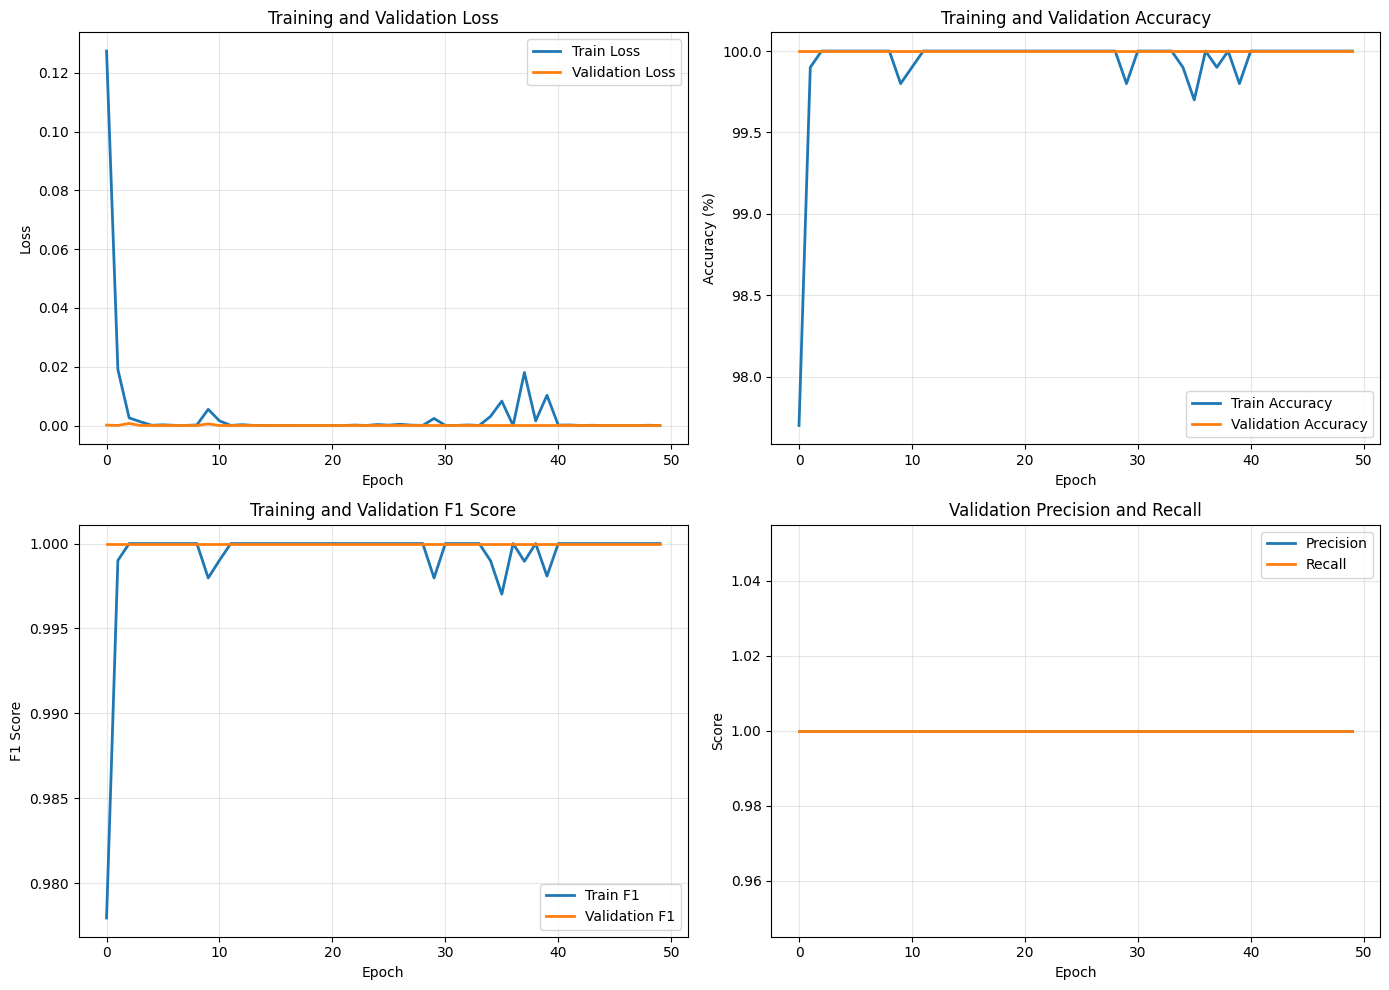

In [12]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0, 0].plot(val_losses, label='Validation Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(train_accuracies, label='Train Accuracy', linewidth=2)
axes[0, 1].plot(val_accuracies, label='Validation Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1 Score
axes[1, 0].plot(train_f1_scores, label='Train F1', linewidth=2)
axes[1, 0].plot(val_f1_scores, label='Validation F1', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('Training and Validation F1 Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Precision and Recall
axes[1, 1].plot(val_precisions, label='Precision', linewidth=2)
axes[1, 1].plot(val_recalls, label='Recall', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Validation Precision and Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


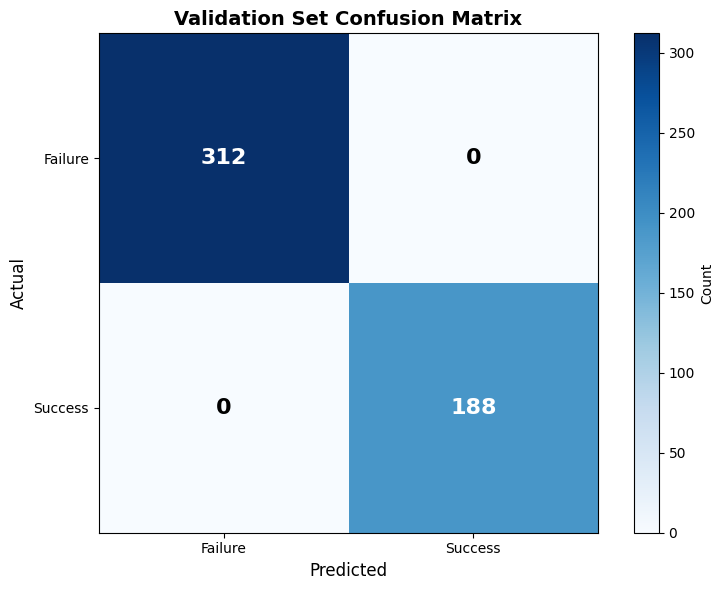

In [13]:
# Plot confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
cm = confusion_matrix(val_labels, val_preds)

try:
    import seaborn as sns
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Failure', 'Success'],
                yticklabels=['Failure', 'Success'],
                cbar_kws={'label': 'Count'})
except ImportError:
    # Fallback if seaborn not available
    im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Count')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', 
                   fontsize=16, fontweight='bold', color='white' if cm[i, j] > cm.max()/2 else 'black')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Failure', 'Success'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Failure', 'Success'])

ax.set_title('Validation Set Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()


In [14]:
# Save the trained model
model_save_path = 'trajectory_classifier_cnn.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {'num_features': 4, 'num_classes': 2},
    'class_weights': class_weights,
    'best_val_f1': best_val_f1,
    'num_epochs': num_epochs,
}, model_save_path)

print(f"✓ Model saved to {model_save_path}")
print(f"  Best validation F1: {best_val_f1:.4f}")


✓ Model saved to trajectory_classifier_cnn.pth
  Best validation F1: 1.0000


In [18]:
# Load test data directly from roa_labels.txt (starting from row 1000, after training)
# Row N in roa_labels.txt corresponds to line N in shuffled_indices.txt

test_start_index = 1000

# Load roa_labels.txt - this is our source of truth for testing
labels_data = np.loadtxt('roa_labels.txt', delimiter=',')

# Get test rows from roa_labels.txt (starting from row 1000)
test_labels_data = labels_data[test_start_index:]
y_test = test_labels_data[:, -1].astype(int)

print(f"Loading test data from roa_labels.txt (starting from row {test_start_index})...")
print(f"Found {len(y_test)} test samples from roa_labels.txt (rows {test_start_index} to {test_start_index + len(y_test) - 1})")

# Get corresponding trajectory sequences from shuffled_indices.txt
with open('shuffled_indices.txt', 'r') as f:
    shuffled_sequences = [line.strip() for line in f.readlines()]

# Get corresponding sequence filenames
test_sequences = shuffled_sequences[test_start_index:]

# Load trajectory sequences
traj_dir = 'trajectories'
max_timesteps = 502
num_features = 4

valid_sequences = []
valid_indices = []
for idx, seq_file in enumerate(test_sequences):
    traj_path = f'{traj_dir}/{seq_file}'
    import os
    if os.path.exists(traj_path):
        valid_sequences.append(seq_file)
        valid_indices.append(test_start_index + idx)

num_seqs = len(valid_sequences)
X_test = np.zeros((num_seqs, max_timesteps, num_features), dtype=np.float32)
y_test_valid = np.zeros(num_seqs, dtype=int)
ids_test = []

print(f"Loading {num_seqs} test trajectories...")
for i, (seq_file, row_idx) in enumerate(zip(valid_sequences, valid_indices)):
    if (i + 1) % 1000 == 0:
        print(f"  Processed {i + 1}/{num_seqs} trajectories...")
    
    traj_path = f'{traj_dir}/{seq_file}'
    trajectory = np.loadtxt(traj_path, delimiter=',')
    if trajectory.ndim == 1:
        trajectory = trajectory.reshape(1, -1)
    
    traj_length = trajectory.shape[0]
    X_test[i, :traj_length, :] = trajectory
    
    # Get label from roa_labels.txt row (row_idx)
    y_test_valid[i] = labels_data[row_idx, -1].astype(int)
    
    # Extract sequence ID
    seq_id = int(seq_file.replace("sequence_", "").replace(".txt", ""))
    ids_test.append(str(seq_id))

ids_test = np.array(ids_test, dtype='<U10')
y_test = y_test_valid  # Use the validated labels

print(f"✓ Loaded {num_seqs} test trajectories")
print(f"  X shape: {X_test.shape}  (trajectories, time_steps, features)")
print(f"  y shape: {y_test.shape}  (labels from roa_labels.txt)")
print(f"  Success rate: {np.mean(y_test == 1):.2%}")
print(f"  Failure rate: {np.mean(y_test == 0):.2%}")

Loading test data from roa_labels.txt (starting from row 1000)...
Found 48770 test samples from roa_labels.txt (rows 1000 to 49769)
Loading 48770 test trajectories...
  Processed 1000/48770 trajectories...
  Processed 2000/48770 trajectories...
  Processed 3000/48770 trajectories...
  Processed 4000/48770 trajectories...
  Processed 5000/48770 trajectories...
  Processed 6000/48770 trajectories...
  Processed 7000/48770 trajectories...
  Processed 8000/48770 trajectories...
  Processed 9000/48770 trajectories...
  Processed 10000/48770 trajectories...
  Processed 11000/48770 trajectories...
  Processed 12000/48770 trajectories...
  Processed 13000/48770 trajectories...
  Processed 14000/48770 trajectories...
  Processed 15000/48770 trajectories...
  Processed 16000/48770 trajectories...
  Processed 17000/48770 trajectories...
  Processed 18000/48770 trajectories...
  Processed 19000/48770 trajectories...
  Processed 20000/48770 trajectories...
  Processed 21000/48770 trajectories...
  

In [19]:
# Create test dataset and dataloader
test_dataset = TrajectoryDataset(X_test, y_test)
test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=0
)

print(f"Test dataset size: {len(test_dataset)}")
print(f"Test batches: {len(test_loader)}")


Test dataset size: 48770
Test batches: 1525


In [20]:
# Evaluate on test set
model.eval()
test_loss = 0
all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        test_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        
        all_test_preds.extend(predicted.cpu().numpy())
        all_test_labels.extend(batch_y.cpu().numpy())

avg_test_loss = test_loss / len(test_loader)
all_test_preds = np.array(all_test_preds)
all_test_labels = np.array(all_test_labels)

# Calculate metrics
test_accuracy = accuracy_score(all_test_labels, all_test_preds)
test_precision = precision_score(all_test_labels, all_test_preds)
test_recall = recall_score(all_test_labels, all_test_preds)
test_f1 = f1_score(all_test_labels, all_test_preds)
test_cm = confusion_matrix(all_test_labels, all_test_preds)

print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"Loss:     {avg_test_loss:.4f}")
print(f"Accuracy: {test_accuracy*100:.2f}%")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")
print()
print("Confusion Matrix:")
print(f"              Predicted")
print(f"              Failure  Success")
print(f"Actual Failure  {test_cm[0,0]:6d}  {test_cm[0,1]:6d}")
print(f"        Success  {test_cm[1,0]:6d}  {test_cm[1,1]:6d}")
print()
print("Classification Report:")
print(classification_report(all_test_labels, all_test_preds, target_names=['Failure', 'Success']))


TEST SET RESULTS
Loss:     0.0009
Accuracy: 99.98%
Precision: 1.0000
Recall:    0.9996
F1 Score:  0.9998

Confusion Matrix:
              Predicted
              Failure  Success
Actual Failure   29953       0
        Success       8   18809

Classification Report:
              precision    recall  f1-score   support

     Failure       1.00      1.00      1.00     29953
     Success       1.00      1.00      1.00     18817

    accuracy                           1.00     48770
   macro avg       1.00      1.00      1.00     48770
weighted avg       1.00      1.00      1.00     48770



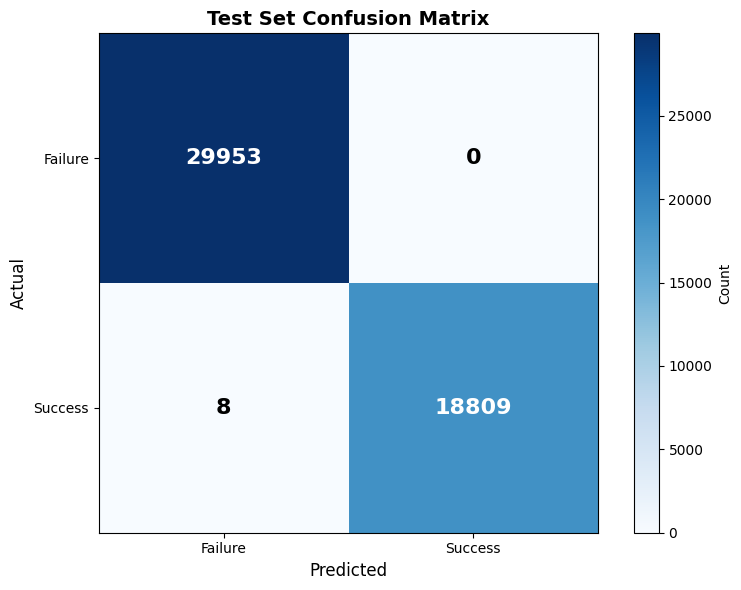

In [21]:
# Plot test set confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

try:
    import seaborn as sns
    sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Failure', 'Success'],
                yticklabels=['Failure', 'Success'],
                cbar_kws={'label': 'Count'})
except ImportError:
    # Fallback if seaborn not available
    im = ax.imshow(test_cm, cmap='Blues', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Count')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(test_cm[i, j]), ha='center', va='center', 
                   fontsize=16, fontweight='bold', color='white' if test_cm[i, j] > test_cm.max()/2 else 'black')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Failure', 'Success'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Failure', 'Success'])

ax.set_title('Test Set Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()


In [24]:
import seaborn as sns

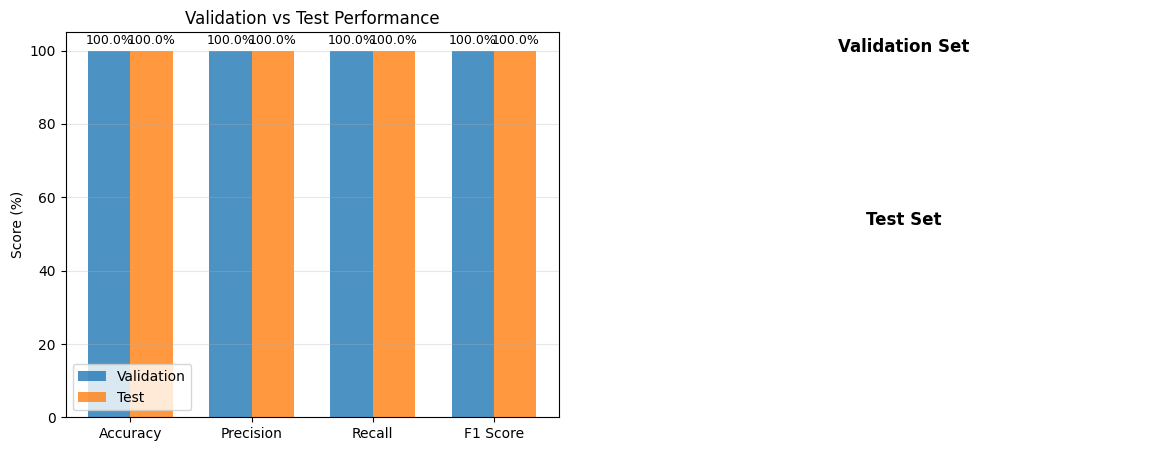

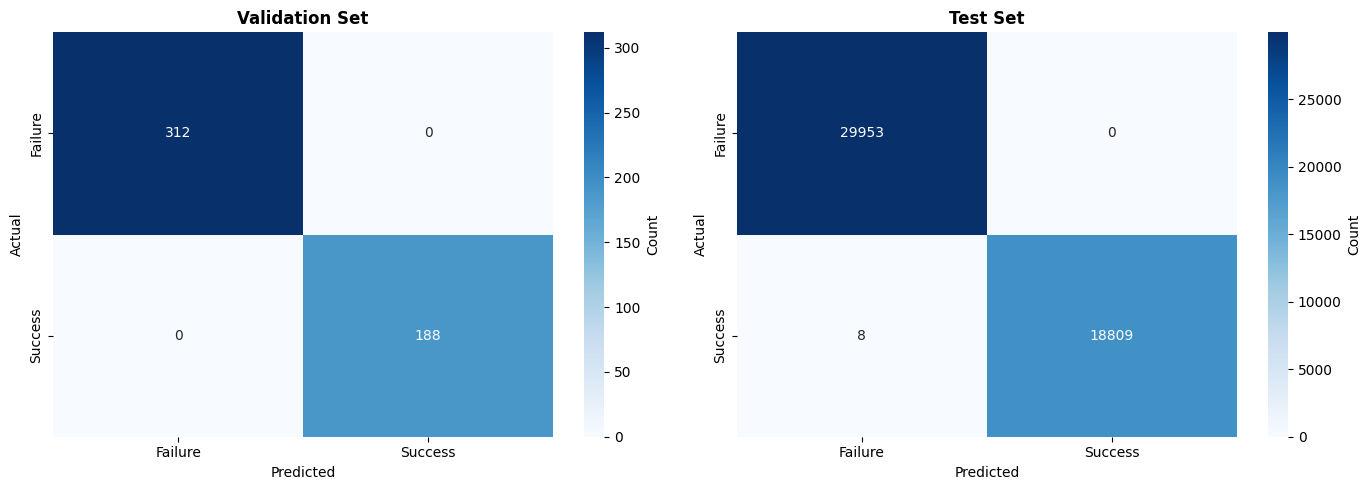

In [25]:
# Compare validation and test performance
# Try to import seaborn for better plots
try:
    import seaborn as sns
    has_seaborn = True
except ImportError:
    has_seaborn = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
val_metrics = [val_acc*100, val_prec*100, val_rec*100, val_f1*100]
test_metrics = [test_accuracy*100, test_precision*100, test_recall*100, test_f1*100]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, val_metrics, width, label='Validation', alpha=0.8)
axes[0].bar(x + width/2, test_metrics, width, label='Test', alpha=0.8)
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Validation vs Test Performance')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0, 105])

# Add value labels on bars
for i, (v, t) in enumerate(zip(val_metrics, test_metrics)):
    axes[0].text(i - width/2, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
    axes[0].text(i + width/2, t + 1, f'{t:.1f}%', ha='center', va='bottom', fontsize=9)

# Confusion matrices side by side
axes[1].axis('off')
axes[1].text(0.5, 0.95, 'Validation Set', ha='center', fontsize=12, fontweight='bold', transform=axes[1].transAxes)
axes[1].text(0.5, 0.5, 'Test Set', ha='center', fontsize=12, fontweight='bold', transform=axes[1].transAxes)

# Create subplot for confusion matrices
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# Validation confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes2[0],
if has_seaborn:
    im1 = axes2[0].imshow(cm, cmap='Blues', interpolation='nearest')
    plt.colorbar(im1, ax=axes2[0], label='Count')
    for i in range(2):
        for j in range(2):
            axes2[0].text(j, i, str(cm[i, j]), ha='center', va='center', 
                         fontsize=14, fontweight='bold', 
                         color='white' if cm[i, j] > cm.max()/2 else 'black')
    axes2[0].set_xticks([0, 1])
    axes2[0].set_xticklabels(['Failure', 'Success'])
    axes2[0].set_yticks([0, 1])
    axes2[0].set_yticklabels(['Failure', 'Success'])

axes2[0].set_title('Validation Set', fontsize=12, fontweight='bold')
axes2[0].set_ylabel('Actual', fontsize=10)
axes2[0].set_xlabel('Predicted', fontsize=10)

# Test confusion matrix
if has_seaborn:
    im2 = axes2[1].imshow(test_cm, cmap='Blues', interpolation='nearest')
    plt.colorbar(im2, ax=axes2[1], label='Count')
    for i in range(2):
        for j in range(2):
            axes2[1].text(j, i, str(test_cm[i, j]), ha='center', va='center', 
                         fontsize=14, fontweight='bold', 
                         color='white' if test_cm[i, j] > test_cm.max()/2 else 'black')
    axes2[1].set_xticks([0, 1])
    axes2[1].set_xticklabels(['Failure', 'Success'])
    axes2[1].set_yticks([0, 1])
    axes2[1].set_yticklabels(['Failure', 'Success'])

axes2[1].set_title('Test Set', fontsize=12, fontweight='bold')
axes2[1].set_ylabel('Actual', fontsize=10)
axes2[1].set_xlabel('Predicted', fontsize=10)

plt.tight_layout()
plt.show()
